In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
import torch.nn as nn
import inspect
from transformers import BertConfig, BertForSequenceClassification

class BertForNLI(nn.Module):
    def __init__(self, vocab_size=30522, num_labels=3):
        super().__init__()
        
        # === Custom BERT config (~23M params) ===
        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=384,
            num_hidden_layers=6,
            num_attention_heads=6,
            intermediate_size=1536,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
            max_position_embeddings=512,
            type_vocab_size=2,
            num_labels=num_labels   # ✅ important for classification
        )
        
        # Classification head instead of MLM
        self.model = BertForSequenceClassification(config)
        

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):
        """
        Forward pass for NLI (sequence classification).
        Returns logits + loss (if labels are provided).
        """
        outputs = self.model(
            input_ids=input_ids,
            token_type_ids=token_type_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        return outputs.logits, outputs.loss if labels is not None else None

    def configure_optimizers(self, weight_decay, learning_rate, device="cuda", verbose=False):
        """
        AdamW optimizer with weight decay only on weight matrices.
        """
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}

        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]

        optim_groups = [
            {"params": decay_params, "weight_decay": weight_decay},
            {"params": nodecay_params, "weight_decay": 0.0},
        ]

        fused_available = "fused" in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and "cuda" in device

        if verbose:
            num_decay = sum(p.numel() for p in decay_params)
            num_nodecay = sum(p.numel() for p in nodecay_params)
            print(f"decay params: {len(decay_params)} tensors, {num_decay/1e6:.2f}M params")
            print(f"nodecay params: {len(nodecay_params)} tensors, {num_nodecay/1e6:.2f}M params")
            print(f"Using fused AdamW: {use_fused}")

        optimizer = torch.optim.AdamW(
            optim_groups,
            lr=learning_rate,
            betas=(0.9, 0.999),
            eps=1e-8,
            fused=use_fused
        )
        return optimizer



# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seeds for reproducibility
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

# Initialize the model
model = BertForNLI(num_labels=3)
model = model.to(device)

total_params = sum(param.numel() for param in model.parameters())
print(f"Total number of parameters: {total_params/1e6}M")


#TF16
torch.set_float32_matmul_precision('high')

2025-10-03 13:46:09.785061: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759499169.971494      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759499170.024408      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Total number of parameters: 22.714371M


In [2]:
#data download and preprocessing

from datasets import load_dataset
from datasets import concatenate_datasets
from transformers import AutoTokenizer
from pympler import asizeof
from torch.utils.data import DataLoader
from collections import Counter

# Load datasets
mnli_dataset = load_dataset("glue", "mnli")
snli_dataset = load_dataset("snli")

# Remove 'idx' column from MNLI
mnli_dataset = {
    split: ds.remove_columns("idx") 
    for split, ds in mnli_dataset.items()
}

# Function to filter out invalid labels
def filter_valid(example):
    return example["label"] != -1

# Filter all SNLI splits
snli_dataset = {
    split: ds.filter(filter_valid)
    for split, ds in snli_dataset.items()
}

# Filter all MNLI splits except test split
mnli_dataset = {
    split: ds.filter(filter_valid) if "test" not in split else ds
    for split, ds in mnli_dataset.items()
}


train_dataset = concatenate_datasets([
    snli_dataset['train'], 
    mnli_dataset['train']
]).shuffle(seed=42)


validation_dataset = concatenate_datasets([
    snli_dataset['validation'], 
    mnli_dataset['validation_matched']
]).shuffle(seed=42)


validation_mismatched_dataset = mnli_dataset['validation_mismatched']


# Check the dataset structure
print(mnli_dataset)
print(snli_dataset)
# print(mnli_dataset["train"][0])  # Look at an example
# print(snli_dataset["train"][0])  # Look at an example

#snli all -1
# print(snli_dataset["test"][0])
# print(mnli_dataset["test_matched"][0])
# print(mnli_dataset["test_mismatched"][0])


# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# tokenize_function with dynamic padding
def tokenize_function(example):
    return tokenizer(
        example["premise"],
        example["hypothesis"],
        padding=False,  # No padding during tokenization
        truncation=True,
        max_length=128
    )

# Tokenize each dataset separately
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_validation = validation_dataset.map(tokenize_function, batched=True)
tokenized_validation_mismatched = validation_mismatched_dataset.map(tokenize_function, batched=True)

# Tokenize test sets (if needed for evaluation)
tokenized_test_mnli_matched = mnli_dataset["test_matched"].map(tokenize_function, batched=True)
tokenized_test_mnli_mismatched = mnli_dataset["test_mismatched"].map(tokenize_function, batched=True)
tokenized_test_snli = snli_dataset["test"].map(tokenize_function, batched=True)


# Change dataset format to use "labels" instead of "label"
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_validation = tokenized_validation.rename_column("label", "labels")
tokenized_validation_mismatched = tokenized_validation_mismatched.rename_column("label", "labels")

tokenized_test_mnli_matched = tokenized_test_mnli_matched.rename_column("label", "labels")
tokenized_test_mnli_mismatched = tokenized_test_mnli_mismatched.rename_column("label", "labels")
tokenized_test_snli = tokenized_test_snli.rename_column("label", "labels")

# Set format for PyTorch
# train and validation split
tokenized_train.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_validation.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_validation_mismatched.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
# test split
tokenized_test_mnli_matched.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_test_mnli_mismatched.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_test_snli.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])



print(f"Train dataset size: {len(tokenized_train)}")
print(f"Validation dataset size: {len(tokenized_validation)}")
print(f"Validation mismatched size: {len(tokenized_validation_mismatched)}")

# attention_mask check 
print(tokenized_train[0]["attention_mask"])  # Expected: [1, 1, ..., 1, 0, ..., 0]

# Check the train dataset dtype and size
size_in_bytes = asizeof.asizeof(tokenized_train)
size_in_mb = size_in_bytes / (1024 * 1024)
print(f"Total size of tokenized_train: {size_in_mb:.2f} MB")

# Check label distribution-count of each sets 0,1,2
train_labels = tokenized_train["labels"].tolist()
print(f"Label distribution in train: {Counter(train_labels)}")

print(tokenized_train[0]["input_ids"].shape, tokenized_train[0]["input_ids"].dtype)
print(tokenized_train[0]["token_type_ids"].shape, tokenized_train[0]["token_type_ids"].dtype)
print(tokenized_train[0]["attention_mask"].shape, tokenized_train[0]["attention_mask"].dtype)
print(tokenized_train[0]["labels"].shape, tokenized_train[0]["labels"].dtype)


# Check data types of each column
sample = tokenized_train[0]  # Get the first example
for key, value in sample.items():
    print(f"Column: {key}, Data Type: {value.dtype}")


README.md: 0.00B [00:00, ?B/s]

mnli/train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

mnli/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/1.21M [00:00<?, ?B/s]

mnli/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/1.25M [00:00<?, ?B/s]

mnli/test_matched-00000-of-00001.parquet:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

...

Map:   0%|          | 0/9832 [00:00<?, ? examples/s]

Map:   0%|          | 0/9796 [00:00<?, ? examples/s]

Map:   0%|          | 0/9847 [00:00<?, ? examples/s]

Map:   0%|          | 0/9824 [00:00<?, ? examples/s]

Train dataset size: 942069
Validation dataset size: 19657
Validation mismatched size: 9832
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Total size of tokenized_train: 629.80 MB
Label distribution in train: Counter({0: 314315, 2: 314090, 1: 313664})
torch.Size([13]) torch.int64
torch.Size([13]) torch.int64
torch.Size([13]) torch.int64
torch.Size([]) torch.int64
Column: labels, Data Type: torch.int64
Column: input_ids, Data Type: torch.int64
Column: token_type_ids, Data Type: torch.int64
Column: attention_mask, Data Type: torch.int64


In [4]:
import os
import math
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
from torch.cuda.amp import GradScaler, autocast
from datetime import datetime, timezone

batch_size = 512

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

train_dataloader = DataLoader(
    tokenized_train,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)
val_matched_dataloader = DataLoader(
    tokenized_validation,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)
val_mismatched_dataloader = DataLoader(
    tokenized_validation_mismatched,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

# Quick check
print(f"Training batches: {len(train_dataloader)}") 
print(f"Validation (matched) batches: {len(val_matched_dataloader)}")
print(f"Validation (mismatched) batches: {len(val_mismatched_dataloader)}")

# batch shape checks 
# batch = next(iter(train_dataloader))
# print(batch["input_ids"].shape, batch["input_ids"].dtype)  # Expected: (32, <=128), torch.int64
# print(batch["labels"].shape, batch["labels"].dtype)  # Expected: (32,), torch.int64



#---------------------------------------Training hyperparameters---------------------------------
num_epochs = 4
max_steps = num_epochs * len(train_dataloader)   #29440-32, 14720-64
grad_clip = 1.0  # Gradient clipping value
eval_interval = 262  # Evaluate every 2000 steps
log_interval = 100  # Log loss every 100 steps

# Setup learning rate scheduler
max_lr = 6e-4
min_lr = 6e-5

warmup_steps = int(0.03 * max_steps)  
plateau = int(0.28 * max_steps)

device = "cuda" if torch.cuda.is_available() else "cpu"



# ---------------------------------cosine learning rate scheduler with warmup------------------------------------------------

def get_lr(it):
    # Linear warm-up
    if it < warmup_steps:
        return max_lr * (it + 1) / warmup_steps
    if it<plateau:
        return max_lr
    # If it > max_steps return min lr
    if it > max_steps:
        return min_lr
    # Cosine decay between warmup and max steps
    decay_ratio = (it - plateau) / (max_steps - plateau)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)


optimizer = model.configure_optimizers(weight_decay=0.1,learning_rate=max_lr,device=device,verbose=True)


# ---------------------------------------------------------------------------------------------------------

# History tracking for plots
train_losses = []
val_matched_losses = []
val_mismatched_losses = []
val_matched_accs = []
val_mismatched_accs = []
steps_history = []


def evaluate(dataloader, split_name):
    """Evaluation function with cleaner progress display"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    # Create a progress bar that updates in place
    progress_bar = tqdm(dataloader, desc=f"Evaluating {split_name}", 
                        leave=True, position=0, 
                        ncols=80,  # Adjust width as needed
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
    
    with torch.no_grad():
        for batch in progress_bar:
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()

            # # Forward pass 
            # logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)            
            # Forward pass
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(input_ids=input_ids, token_type_ids=token_type_ids, attention_mask=attention_mask, labels=labels)
            
            # Get predictions
            preds = torch.argmax(logits, dim=-1)
            
            # Track predictions and labels
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()
            
            # Update progress bar with current accuracy
            current_acc = (preds == labels).sum().item() / labels.size(0)
            progress_bar.set_postfix(batch_acc=f"{current_acc:.4f}", 
                                    loss=f"{loss.item():.4f}",
                                    refresh=False)
    
    # Calculate metrics
    accuracy = correct / total
    avg_loss = total_loss / len(dataloader)
    
    # Print final metrics
    print(f"\n{split_name} Results | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")
    
    return {
        "loss": avg_loss,
        "accuracy": accuracy
    }

def plot_training_history():
    """Plot training and validation metrics."""
    plt.figure(figsize=(12, 8))
    
    # Plot losses
    plt.subplot(2, 1, 1)
    plt.plot(steps_history, train_losses, label='Train Loss')
    plt.plot(steps_history, val_matched_losses, label='Val Matched Loss')
    plt.plot(steps_history, val_mismatched_losses, label='Val Mismatched Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot accuracies
    plt.subplot(2, 1, 2)
    plt.plot(steps_history, val_matched_accs, label='Val Matched Accuracy')
    plt.plot(steps_history, val_mismatched_accs, label='Val Mismatched Accuracy')
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()
    print("Training history plot saved to 'training_history.png'")

# Main training function
def train():
    global_step = 0
    best_val_acc = 0.0
    start_time = time.time()  # Start timer
    
    # Initialize history tracking
    global train_losses, val_matched_losses, val_mismatched_losses
    global val_matched_accs, val_mismatched_accs, steps_history
    
    # Main training loop
    for epoch in range(num_epochs):
        print(f"Starting epoch {epoch+1}/{num_epochs}")
        model.train()
        
        # Track metrics for this epoch
        epoch_losses = []
        
        # Use standard PyTorch dataloader iteration
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")
        for batch in progress_bar:
            if global_step >= max_steps:
                break
                
            t0 = time.time()
            
            # Get batch data and move to device
            input_ids = batch["input_ids"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()
            
            
            # Zero gradients
            optimizer.zero_grad()
            
            # # Forward pass 
            # logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)

            #-------------------------------------autocast---------------------------------
            with torch.autocast(device_type=device,dtype=torch.bfloat16):
                    logits,loss = model(input_ids=input_ids, token_type_ids=token_type_ids, attention_mask=attention_mask, labels=labels)
            
            #------------------------------------------------------------------------------
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            # Update learning rate
            lr = get_lr(global_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            
            # Update weights
            optimizer.step()
            
            # Track epoch loss
            current_loss = loss.item()
            epoch_losses.append(current_loss)
            
            # Synchronize CUDA for accurate timing
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            
            # Calculate speed metrics
            t1 = time.time()
            dt = (t1 - t0)
            
            # Tokens processed calculation
            batch_size = input_ids.size(0)
            sequence_length = input_ids.size(1)
            tokens_processed = batch_size * sequence_length
            tokens_per_sec = tokens_processed / dt
            
            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'lr': f'{lr:.2e}',
                'tok/s': f'{tokens_per_sec:.0f}'
            })
            
            # Log training metrics
            if global_step % log_interval == 0:
                print(f'step {global_step:6d} | loss: {current_loss:.6f} | lr: {lr:.4e} | '
                      f'dt: {dt*1000:.2f}ms | norm: {norm:.4f} | tok/sec: {tokens_per_sec:.2f}')
            
            # Evaluation
            if global_step > 0 and global_step % eval_interval == 0:
                print(f"\nEvaluating at step {global_step}...")
                val_matched_metrics = evaluate(val_matched_dataloader, "val_matched")
                val_mismatched_metrics = evaluate(val_mismatched_dataloader, "val_mismatched")
                
                # Calculate average validation accuracy
                val_acc = val_matched_metrics["accuracy"] #(+ val_mismatched_metrics["accuracy"]) / 2
                
                # Track metrics for plotting
                avg_train_loss = sum(epoch_losses[-100:]) / min(len(epoch_losses), 100)  # Average of last 100 steps
                train_losses.append(avg_train_loss)
                val_matched_losses.append(val_matched_metrics["loss"])
                val_mismatched_losses.append(val_mismatched_metrics["loss"])
                val_matched_accs.append(val_matched_metrics["accuracy"])
                val_mismatched_accs.append(val_mismatched_metrics["accuracy"])
                steps_history.append(global_step)
                
                # Save best model
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    torch.save(model.state_dict(), "best_model.pt")
                    print(f"New best validation accuracy: {best_val_acc:.4f}")
                
                # Generate and save plots
                plot_training_history()
                
                # Back to training mode
                model.train()
                print("")  # Add empty line for readability
            
            # Increment global step
            global_step += 1
        
        # End of epoch
        epoch_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"\nEpoch {epoch+1} completed | Average loss: {epoch_loss:.6f}")
        
    # Save final model
    torch.save(model.state_dict(), "final_model.pt")
    end_time = time.time()  # End timer
    elapsed = end_time - start_time

    # Save training time
    elapsed_str = datetime.fromtimestamp(elapsed, tz=timezone.utc).strftime("%H:%M:%S")
    print(f"\nTraining completed in {elapsed:.2f} seconds ({elapsed_str})")
    print("Training completed. Final model saved to 'final_model.pt'")

Training batches: 1840
Validation (matched) batches: 39
Validation (mismatched) batches: 20
decay params: 41 tensors, 22.68M params
nodecay params: 64 tensors, 0.03M params
Using fused AdamW: True


In [5]:
train()


Starting epoch 1/4


Epoch 1:   0%|          | 0/1840 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
Epoch 1:   0%|          | 1/1840 [00:01<59:01,  1.93s/it, loss=1.1124, lr=2.73e-06, tok/s=33795]

step      0 | loss: 1.112389 | lr: 2.7273e-06 | dt: 1727.11ms | norm: 1.1054 | tok/sec: 33795.11


Epoch 1:   5%|▌         | 101/1840 [01:50<31:22,  1.08s/it, loss=1.0599, lr=2.75e-04, tok/s=60893]

step    100 | loss: 1.059875 | lr: 2.7545e-04 | dt: 1076.26ms | norm: 0.7541 | tok/sec: 60892.63


...


val_mismatched Results | Loss: 0.7577 | Accuracy: 0.6765
New best validation accuracy: 0.7349


Epoch 4:  99%|█████████▉| 1817/1840 [35:53<03:20,  8.73s/it, loss=0.5905, lr=6.00e-05, tok/s=60859]

Training history plot saved to 'training_history.png'



Epoch 4: 100%|██████████| 1840/1840 [36:18<00:00,  1.18s/it, loss=0.5452, lr=6.00e-05, tok/s=60782]


Epoch 4 completed | Average loss: 0.590123

Training completed in 8691.71 seconds (02:24:51)
Training completed. Final model saved to 'final_model.pt'


In [6]:
batch_size = 512

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

test_matched_mnli_dataloader = DataLoader(
    tokenized_test_mnli_matched,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)
test_mismatched_mnli_dataloader = DataLoader(
    tokenized_test_mnli_mismatched,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)
test_snli_dataloader = DataLoader(
    tokenized_test_snli,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)



print(f"Test matched size: {len(tokenized_test_mnli_matched)}")
print(f"Test mismatched size: {len(tokenized_test_mnli_mismatched)}")
print(f"Test SNLI size: {len(tokenized_test_snli)}")


Test matched size: 9796
Test mismatched size: 9847
Test SNLI size: 9824



=== SNLI Test Result Evaluation ===
Loss: 0.4982 | Accuracy: 0.8001 | F1 (weighted): 0.8003

=== Confusion Matrix Visualization ===


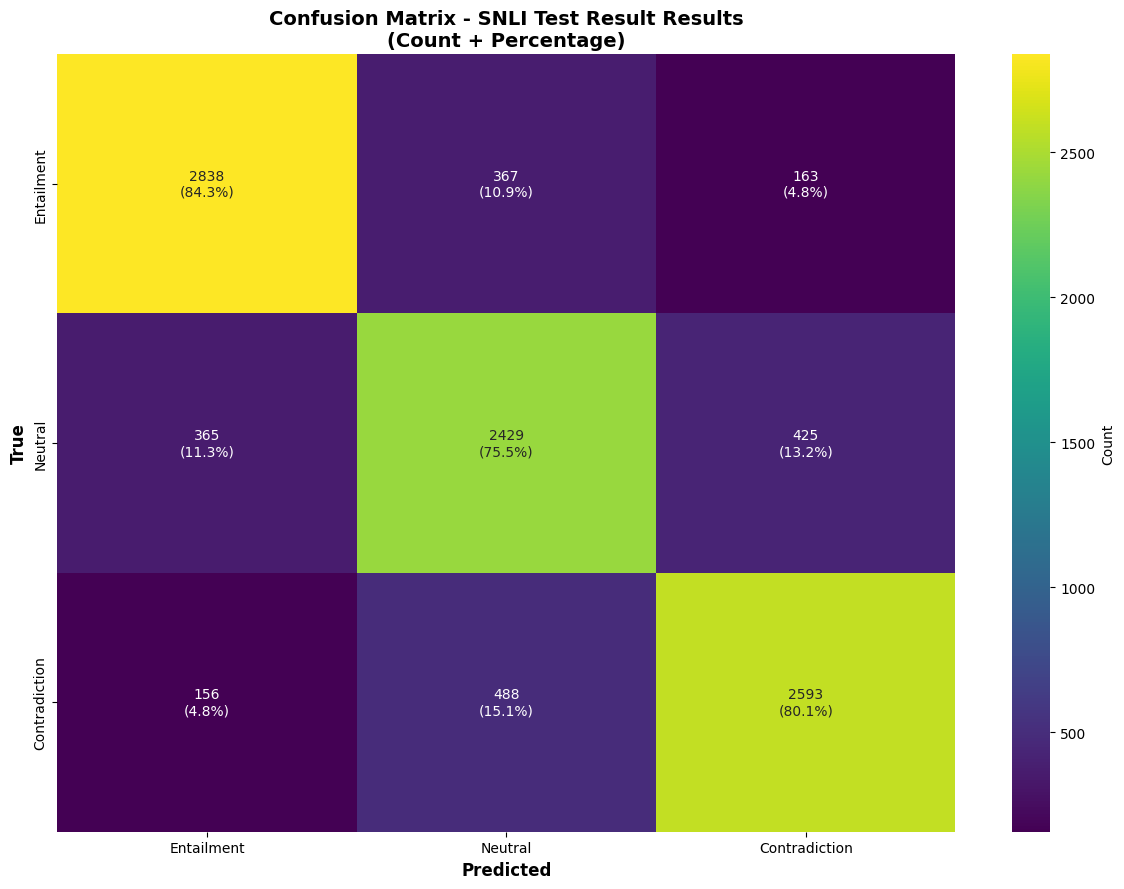

Confusion matrix saved to confusion_matrix_snli_test_result_20251003_162714.png

Classification Report - SNLI Test Result:
               precision    recall  f1-score   support

   Entailment       0.84      0.84      0.84      3368
      Neutral       0.74      0.75      0.75      3219
Contradiction       0.82      0.80      0.81      3237

     accuracy                           0.80      9824
    macro avg       0.80      0.80      0.80      9824
 weighted avg       0.80      0.80      0.80      9824


Per-Class Accuracy:
Entailment: 0.8426 accuracy (2838/3368)
Neutral: 0.7546 accuracy (2429/3219)
Contradiction: 0.8011 accuracy (2593/3237)

=== Summary of SNLI Test Evaluation ===
Loss: 0.4982
Accuracy: 0.8001
F1 (weighted): 0.8003
F1 (macro): 0.7996
F1 (micro): 0.8001

Per-Class Accuracy:
Entailment: 0.8426 (2838/3368)
Neutral: 0.7546 (2429/3219)
Contradiction: 0.8011 (2593/3237)


In [9]:
# final evaluation on test set

import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score, classification_report


def final_evaluation(model, dataloader, split_name, class_names=None, device=None):
    """
    Comprehensive evaluation function for final reporting on a dataset, excluding high-confidence error analysis.
    
    Args:
        model: PyTorch model in evaluation mode.
        dataloader: PyTorch DataLoader with input_ids, token_type_ids, label, attention_mask.
        split_name (str): Name of the dataset split (e.g., "Test", "Val Matched").
        class_names (list): List of class names (e.g., ["Entailment", "Neutral", "Contradiction"]). 
                           Defaults to None, using numeric labels if not provided.
        device: Torch device (e.g., torch.device("cuda")). If None, uses model's device.
    
    Returns:
        dict: Metrics including loss, accuracy, F1 scores, confusion matrix, and per-class accuracy.
    """
    if device is None:
        device = next(model.parameters()).device
    
    if class_names is None:
        class_names = [f"Class {i}" for i in range(3)]  # Default for 3-class NLI task
    
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    num_examples = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {split_name}", leave=False):
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()
            
            # Forward pass
            logits, loss = model(input_ids=input_ids, token_type_ids=token_type_ids, labels=labels, attention_mask=attention_mask)
            
            # Compute predictions
            preds = torch.argmax(logits, dim=-1)
            
            # Track predictions and labels
            batch_size = input_ids.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            total_loss += loss.item() * batch_size
            num_examples += batch_size
    
    # Convert to numpy arrays for sklearn
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate basic metrics
    correct = np.sum(y_true == y_pred)
    accuracy = correct / len(y_true)
    avg_loss = total_loss / num_examples  # Weighted average by batch size
    
    # Calculate F1 scores
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class accuracy
    per_class_accuracy = {}
    for cls_idx, cls_name in enumerate(class_names):
        cls_indices = np.where(y_true == cls_idx)[0]
        cls_correct = np.sum(y_pred[cls_indices] == y_true[cls_indices])
        cls_acc = cls_correct / len(cls_indices) if len(cls_indices) > 0 else 0
        per_class_accuracy[cls_name] = {
            "accuracy": cls_acc,
            "correct": int(cls_correct),
            "total": len(cls_indices)
        }
    
    # Print metrics
    print(f"\n=== {split_name} Evaluation ===")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f} | F1 (weighted): {f1_weighted:.4f}")
    
    # Enhanced confusion matrix visualization
    print(f"\n=== Confusion Matrix Visualization ===")
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    plt.figure(figsize=(12, 9))
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create custom annotations with count + percentage
    annotations = []
    for i in range(cm.shape[0]):
        row = []
        for j in range(cm.shape[1]):
            row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
        annotations.append(row)
    
    sns.heatmap(cm, annot=annotations, fmt='', cmap='viridis', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    plt.title(f'Confusion Matrix - {split_name} Results\n(Count + Percentage)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    plot_filename = f'confusion_matrix_{split_name.lower().replace(" ", "_")}_{timestamp}.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Confusion matrix saved to {plot_filename}")
    
    # Print classification report
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(f"\nClassification Report - {split_name}:\n{report}")
    
    # Print per-class accuracy
    print(f"\nPer-Class Accuracy:")
    for cls_name, stats in per_class_accuracy.items():
        print(f"{cls_name}: {stats['accuracy']:.4f} accuracy "
              f"({stats['correct']}/{stats['total']})")
    
    # Return comprehensive metrics
    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "f1_micro": f1_micro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm.tolist(),
        "per_class_accuracy": per_class_accuracy
    }


# Load the saved model weights
model = BertForNLI(num_labels=3).to(device)  # Move model to the appropriate device    
model.load_state_dict(torch.load("best_model.pt"))  # Load the best weights
model.eval()  # Set model to evaluation mode

# Define class names for NLI task
class_names = ["Entailment", "Neutral", "Contradiction"]

# Run final evaluation on tokenized_test_mnli_matched
metrics = final_evaluation(
    model=model,
    dataloader=test_snli_dataloader,
    split_name="SNLI Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of SNLI Test Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")



best_model.pt					       final_model.pt
confusion_matrix_snli_test_result_20251003_162714.png  training_history.png


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


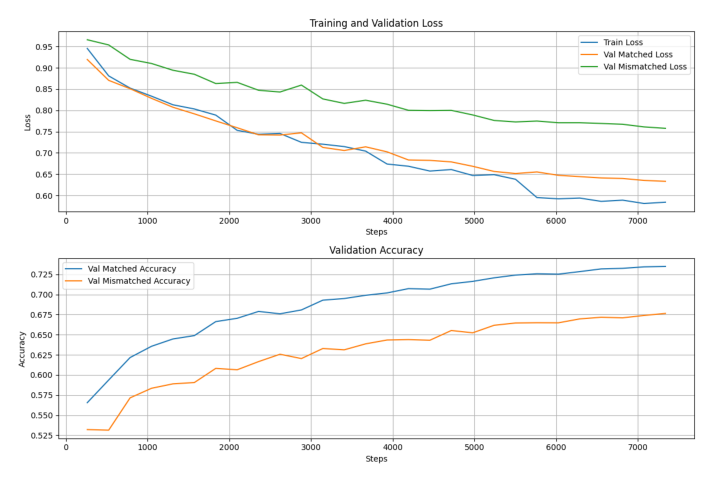


=== Confusion Matrix Visualization ===


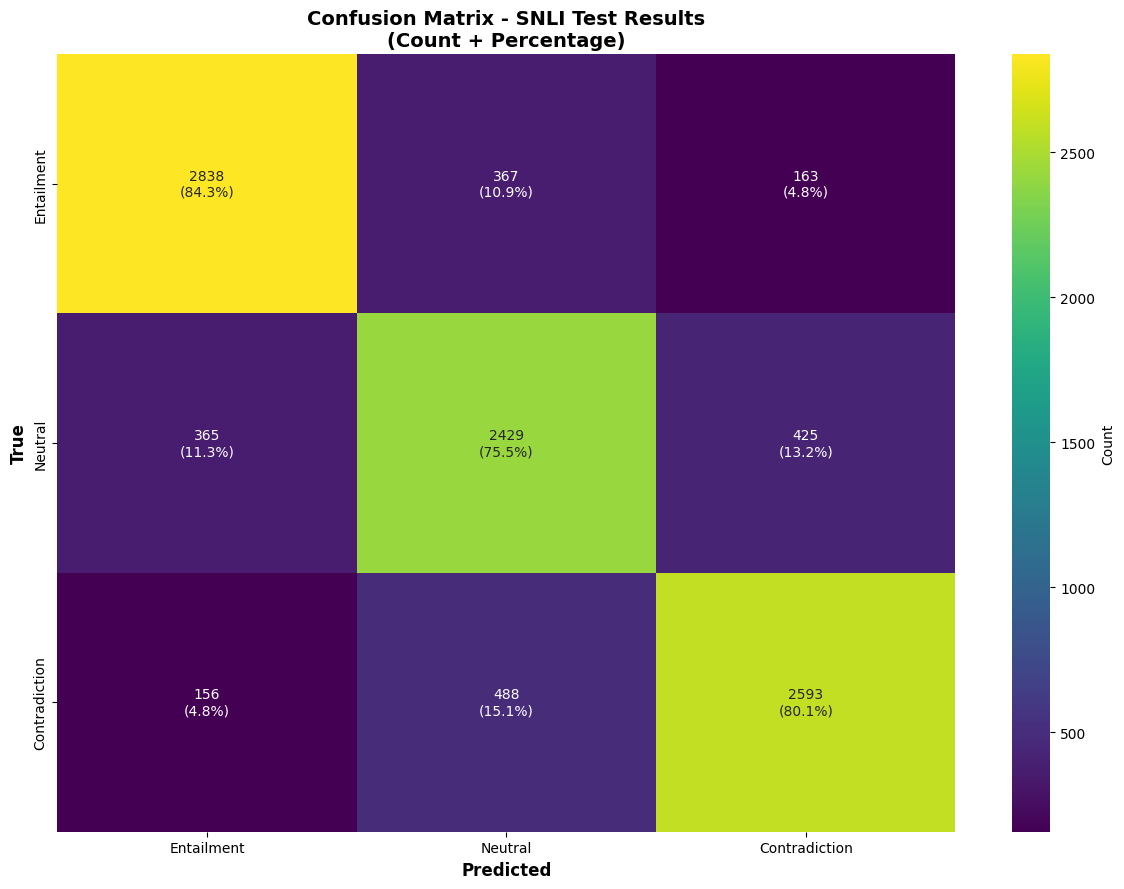

In [10]:
!ls
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('training_history.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

# Display the confusion matrix heatmap again
print("\n=== Confusion Matrix Visualization ===")
plt.figure(figsize=(12, 9))
cm = np.array(metrics['confusion_matrix'])

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create custom annotations with count + percentage
annotations = []
for i in range(cm.shape[0]):
    row = []
    for j in range(cm.shape[1]):
        row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
    annotations.append(row)

sns.heatmap(cm, annot=annotations, fmt='', cmap='viridis',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('True', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - SNLI Test Results\n(Count + Percentage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()  # This will display the plot

In [ ]:
# anli dataset preprocessing
from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding

# Load the ANLI dataset
anli_dataset = load_dataset("anli")
# print(anli_dataset) #original structure


# Remove 'uid' and 'reason' columns from all ANLI splits
anli_dataset = {
    split: ds.remove_columns(["uid", "reason"])
    for split, ds in anli_dataset.items()
}

# Function to filter out invalid labels
def filter_valid(example):
    return example["label"] != -1

# Filter all SNLI splits
anli_dataset = {
    split: ds.filter(filter_valid)
    for split, ds in anli_dataset.items()
}

print(anli_dataset)

# Look at an example from each round
# print("R1 example:", anli_dataset["test_r1"][0])
# print("R2 example:", anli_dataset["test_r2"][0])
# print("R3 example:", anli_dataset["test_r3"][0])

#combine r1,r2,r3

test_dataset_anli_r123 = concatenate_datasets([
    anli_dataset["test_r1"],
    anli_dataset["test_r2"],
    anli_dataset["test_r3"]
]).shuffle(seed=42)


# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


def tokenize_function(example):
    return tokenizer(
        example["premise"],
        example["hypothesis"],
        padding=False,  # No padding during tokenization
        truncation=True,
        max_length=128
    )

# Tokenize each dataset separately
tokenized_anli_test_r1 = anli_dataset["test_r1"].map(tokenize_function, batched=True)
tokenized_anli_test_r2 = anli_dataset["test_r2"].map(tokenize_function, batched=True)
tokenized_anli_test_r3 = anli_dataset["test_r3"].map(tokenize_function, batched=True)

tokenized_anli_test_r123 = test_dataset_anli_r123.map(tokenize_function, batched=True)


tokenized_anli_test_r1 = tokenized_anli_test_r1.rename_column("label", "labels")
tokenized_anli_test_r2 = tokenized_anli_test_r2.rename_column("label", "labels")
tokenized_anli_test_r3 = tokenized_anli_test_r3.rename_column("label", "labels")
tokenized_anli_test_r123 = tokenized_anli_test_r123.rename_column("label", "labels")

tokenized_anli_test_r1.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_anli_test_r2.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_anli_test_r3.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_anli_test_r123.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])


batch_size = 512

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

anli_test_r1_dataloader = DataLoader(
    tokenized_anli_test_r1,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

anli_test_r2_dataloader = DataLoader(
    tokenized_anli_test_r2,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

anli_test_r3_dataloader = DataLoader(
    tokenized_anli_test_r3,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

anli_test_r123_dataloader = DataLoader(
    tokenized_anli_test_r123,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

README.md: 0.00B [00:00, ?B/s]

plain_text/train_r1-00000-of-00001.parqu(…):   0%|          | 0.00/3.14M [00:00<?, ?B/s]

plain_text/dev_r1-00000-of-00001.parquet:   0%|          | 0.00/351k [00:00<?, ?B/s]

plain_text/test_r1-00000-of-00001.parque(…):   0%|          | 0.00/353k [00:00<?, ?B/s]

plain_text/train_r2-00000-of-00001.parqu(…):   0%|          | 0.00/6.53M [00:00<?, ?B/s]

...

{'train_r1': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 16946
}), 'dev_r1': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1000
}), 'test_r1': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1000
}), 'train_r2': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 45460
}), 'dev_r2': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1000
}), 'test_r2': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1000
}), 'train_r3': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 100459
}), 'dev_r3': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1200
}), 'test_r3': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1200
})}


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Evaluating ANLI R2 0-shot Test Result:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R2 0-shot Test Result Evaluation ===
Loss: 1.6059 | Accuracy: 0.2960 | F1 (weighted): 0.2908

=== Confusion Matrix Visualization ===


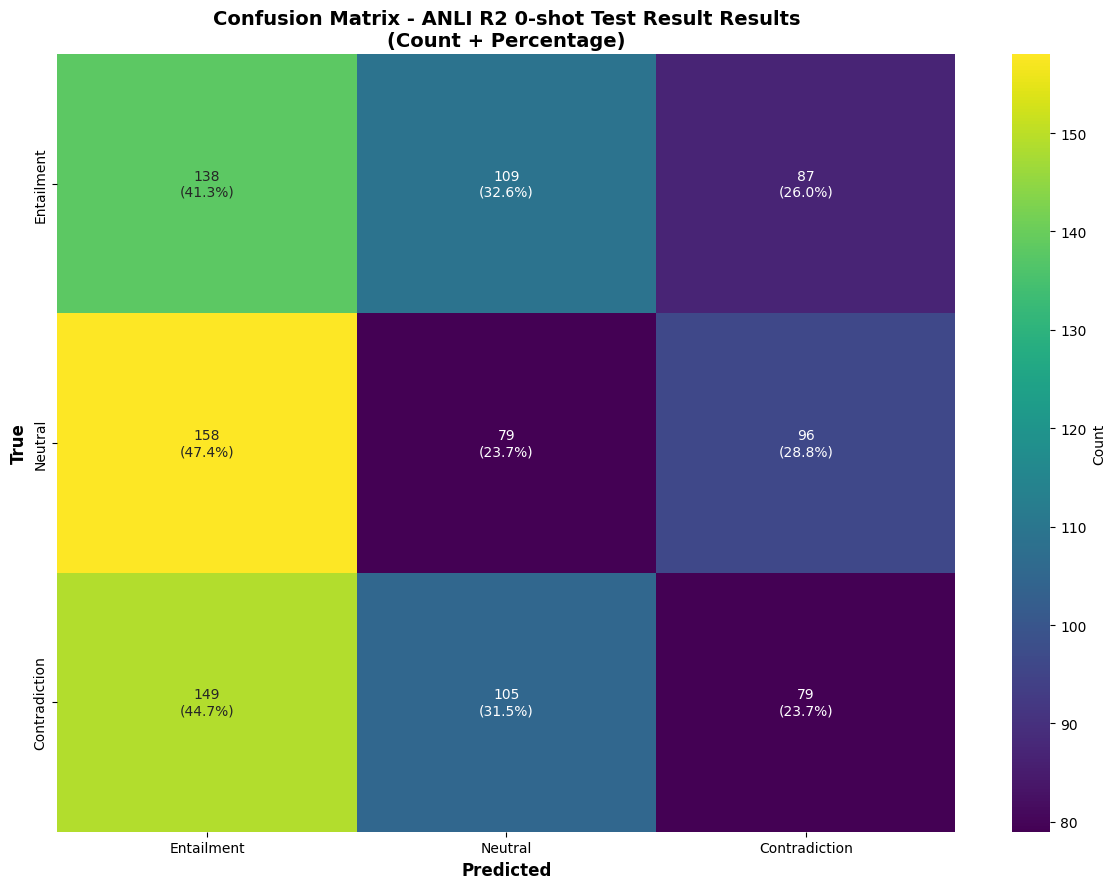

Confusion matrix saved to confusion_matrix_anli_r2_0-shot_test_result_20251003_163017.png

Classification Report - ANLI R2 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.31      0.41      0.35       334
      Neutral       0.27      0.24      0.25       333
Contradiction       0.30      0.24      0.27       333

     accuracy                           0.30      1000
    macro avg       0.29      0.30      0.29      1000
 weighted avg       0.29      0.30      0.29      1000


Per-Class Accuracy:
Entailment: 0.4132 accuracy (138/334)
Neutral: 0.2372 accuracy (79/333)
Contradiction: 0.2372 accuracy (79/333)

=== Summary of ANLI Test R2 Evaluation ===
Loss: 1.6059
Accuracy: 0.2960
F1 (weighted): 0.2908
F1 (macro): 0.2907
F1 (micro): 0.2960

Per-Class Accuracy:
Entailment: 0.4132 (138/334)
Neutral: 0.2372 (79/333)
Contradiction: 0.2372 (79/333)


Evaluating ANLI R3 0-shot Test Result:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R3 0-shot Test Result Evaluation ===
Loss: 1.5805 | Accuracy: 0.2792 | F1 (weighted): 0.2781

=== Confusion Matrix Visualization ===


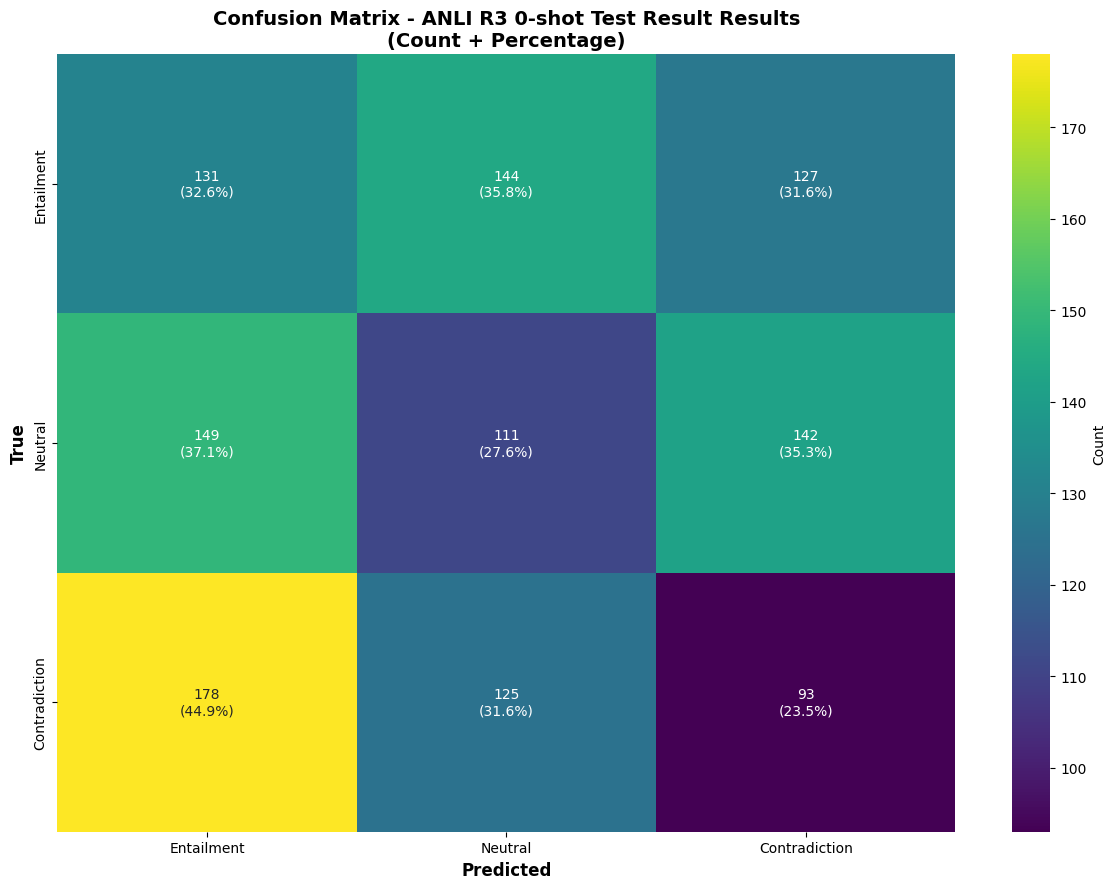

Confusion matrix saved to confusion_matrix_anli_r3_0-shot_test_result_20251003_163019.png

Classification Report - ANLI R3 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.29      0.33      0.30       402
      Neutral       0.29      0.28      0.28       402
Contradiction       0.26      0.23      0.25       396

     accuracy                           0.28      1200
    macro avg       0.28      0.28      0.28      1200
 weighted avg       0.28      0.28      0.28      1200


Per-Class Accuracy:
Entailment: 0.3259 accuracy (131/402)
Neutral: 0.2761 accuracy (111/402)
Contradiction: 0.2348 accuracy (93/396)

=== Summary of ANLI Test R3 Evaluation ===
Loss: 1.5805
Accuracy: 0.2792
F1 (weighted): 0.2781
F1 (macro): 0.2780
F1 (micro): 0.2792

Per-Class Accuracy:
Entailment: 0.3259 (131/402)
Neutral: 0.2761 (111/402)
Contradiction: 0.2348 (93/396)


In [12]:
# Run final evaluation on tokenized_test_ANLI
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r2_dataloader,
    split_name="ANLI R2 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R2 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")


# Run final evaluation on tokenized_test_ANLI
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r3_dataloader,
    split_name="ANLI R3 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R3 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")


Evaluating ANLI R1 0-shot Test Result:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R1 0-shot Test Result Evaluation ===
Loss: 1.7409 | Accuracy: 0.2290 | F1 (weighted): 0.2199

=== Confusion Matrix Visualization ===


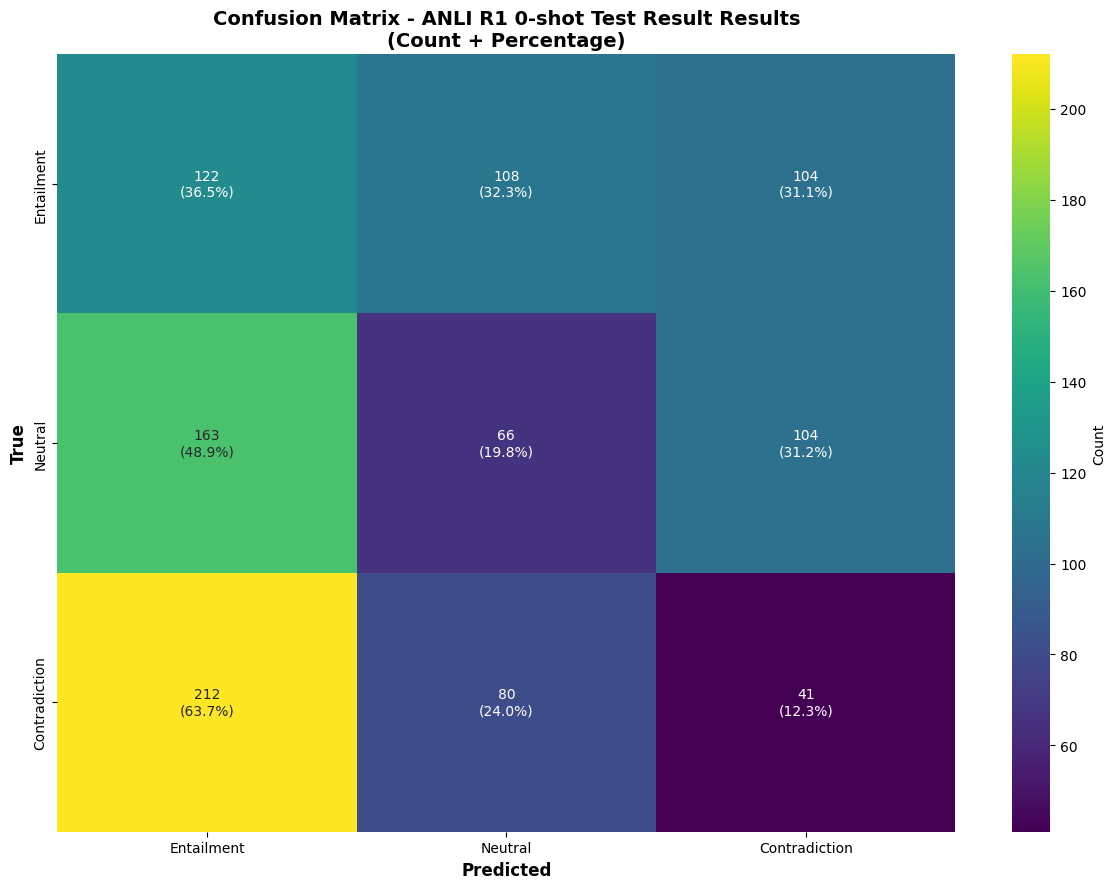

Confusion matrix saved to confusion_matrix_anli_r1_0-shot_test_result_20251003_163224.png

Classification Report - ANLI R1 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.25      0.37      0.29       334
      Neutral       0.26      0.20      0.22       333
Contradiction       0.16      0.12      0.14       333

     accuracy                           0.23      1000
    macro avg       0.22      0.23      0.22      1000
 weighted avg       0.22      0.23      0.22      1000


Per-Class Accuracy:
Entailment: 0.3653 accuracy (122/334)
Neutral: 0.1982 accuracy (66/333)
Contradiction: 0.1231 accuracy (41/333)

=== Summary of ANLI Test R123 Evaluation ===
Loss: 1.7409
Accuracy: 0.2290
F1 (weighted): 0.2199
F1 (macro): 0.2198
F1 (micro): 0.2290

Per-Class Accuracy:
Entailment: 0.3653 (122/334)
Neutral: 0.1982 (66/333)
Contradiction: 0.1231 (41/333)


In [13]:
# Run final evaluation on tokenized_test_mnli_matched
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r1_dataloader,
    split_name="ANLI R1 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R123 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")


In [15]:
# inference

import torch
# from model_file import BERT, BERTConfig  # Import your model architecture

def load_model_for_inference(model_path, device="cuda"):
    # Initialize model with the same config as training
    model = BertForNLI(num_labels=3).to(device)
    
    # Load weights
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)
    model.eval()  # Set to evaluation mode
    
    return model

def predict(model, tokenizer, premise, hypothesis, device="cuda"):
    # Tokenize input
    inputs = tokenizer(
        premise, 
        hypothesis,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    
    # Move to device
    input_ids = inputs["input_ids"].to(device)
    token_type_ids = inputs["token_type_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device).bool()
    
    # Inference
    with torch.no_grad():
        logits, _ = model(input_ids=input_ids, token_type_ids=token_type_ids, attention_mask=attention_mask)
        predictions = torch.argmax(logits, dim=-1)
    
    # Map to label names
    label_map = {0: "entailment", 1: "neutral", 2: "contradiction"}
    return label_map[predictions.item()]

# Example usage
model = load_model_for_inference("best_model.pt")
result = predict(model, tokenizer, 
                "The man is walking down the street.", 
                "A person is outside.")
print(f"Prediction: {result}")

Prediction: entailment
